# 🛠️ Étape 2 : Préparation des Données et Feature Engineering
**Objectif :** Nettoyer les données, vérifier la corrélation entre nos variables (pour éviter la colinéarité) et préparer notre stratégie de mise à l'échelle (Scaling).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Chargement des données
df = pd.read_csv('../data/rocket_league_skill_data.csv')
X = df.drop(columns=['Target'])
y = df['Target']

### 🔗 1. Matrice de Corrélation
Avant de donner nos variables à un modèle, vérifions qu'elles ne font pas "doublon". Si deux variables sont corrélées à 100%, l'une des deux est inutile et risque de perturber la Régression Logistique.

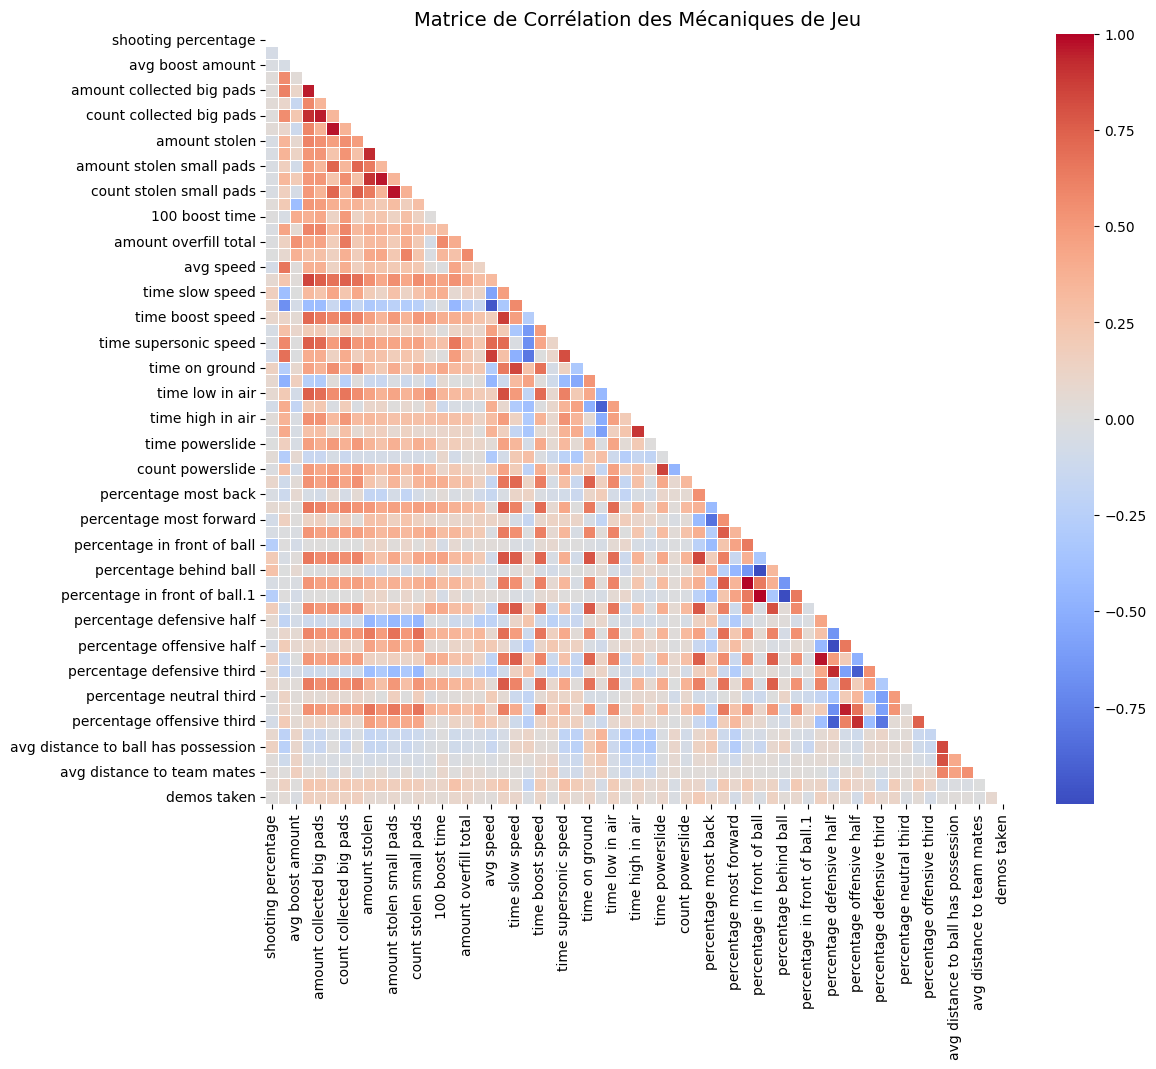

In [2]:
plt.figure(figsize=(12, 10))
# On calcule la corrélation de Spearman (robuste aux valeurs extrêmes)
corr_matrix = X.corr(method='spearman')

# On masque la moitié supérieure du graphique pour la lisibilité
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, annot=False, linewidths=.5)
plt.title("Matrice de Corrélation des Mécaniques de Jeu", fontsize=14)
plt.show()

### 📏 2. Stratégie de Standardisation (Scaling)
Nos variables ont des échelles très différentes : `avg speed` est en milliers (ex: 1500 u/s), tandis que `percentage supersonic speed` est un pourcentage (ex: 15%). 
Les algorithmes comme la Régression Logistique ou les SVM sont très sensibles à ces différences d'échelle. 

**Décision d'ingénierie :** Nous n'allons pas modifier le dataset brut directement ici pour éviter le "Data Leakage" (fuite de données). Nous intégrerons un `StandardScaler` directement dans un `Pipeline` scikit-learn lors de la modélisation.